# Car Price Prediction Project

In [820]:
import pandas as pd

## 1. Data Loading

In [821]:
df = pd.read_csv('car data.csv')
print('Dataset loaded successfully!')
display(df.head())

Dataset loaded successfully!


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Data Exploration and Preprocessing

In [822]:
df.shape

(301, 9)

In [823]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [824]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [825]:
df.duplicated().sum()

np.int64(2)

In [826]:
df.drop_duplicates(inplace=True)

In [827]:
df.duplicated().sum()

np.int64(0)

In [828]:
print('\nDataFrame Info:')
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [829]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [830]:
from datetime import date

current_year = date.today().year

df['Car_Age'] = current_year - df['Year']

df.drop('Year', axis=1, inplace=True)

print('New feature "Car_Age" created and "Year" column dropped.')
display(df.head())

New feature "Car_Age" created and "Year" column dropped.


,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [831]:
object_columns = df.select_dtypes(include='object').columns
print('Object type columns:', object_columns.tolist())

Object type columns: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [832]:
print('\nUnique values in Fuel_Type:', df['Fuel_Type'].unique())
print('Unique values in Selling_type:', df['Selling_type'].unique())
print('Unique values in Transmission:', df['Transmission'].unique())
print('Number of unique Car_Names:', len(df['Car_Name'].unique()))
print('Some unique Car_Names:', df['Car_Name'].unique()[:10])


Unique values in Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Unique values in Selling_type: ['Dealer' 'Individual']
Unique values in Transmission: ['Manual' 'Automatic']
Number of unique Car_Names: 98
Some unique Car_Names: ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire']


In [833]:
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

df = pd.get_dummies(df, columns=['Car_Name'], drop_first=True)

print('Categorical features one-hot encoded.')
display(df.head())

Categorical features one-hot encoded.


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Car_Name_Activa 3g,...,Car_Name_land cruiser,Car_Name_omni,Car_Name_ritz,Car_Name_s cross,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent
0,3.35,5.59,27000,0,12,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,13,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,7.25,9.85,6900,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,15,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,4.60,6.87,42450,0,12,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [834]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Columns: 106 entries, Selling_Price to Car_Name_xcent
dtypes: bool(101), float64(2), int64(3)
memory usage: 43.5 KB


## 3. Model Training

In [835]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print('Features (X) and target (y) defined.')
print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Features (X) and target (y) defined.
Shape of X: (299, 105)
Shape of y: (299,)


In [836]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data split into training and testing sets.')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

Data split into training and testing sets.
X_train shape: (239, 105)
X_test shape: (60, 105)
y_train shape: (239,)
y_test shape: (60,)


In [837]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print('Random Forest Regressor model trained successfully.')

Random Forest Regressor model trained successfully.


## 4. Model Evaluation

In [838]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'R-squared (R2) score: {r2:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

R-squared (R2) score: 0.62
Mean Absolute Error (MAE): 1.31
Mean Squared Error (MSE): 9.76
Root Mean Squared Error (RMSE): 3.12


## 5. Visualizing Model Performance

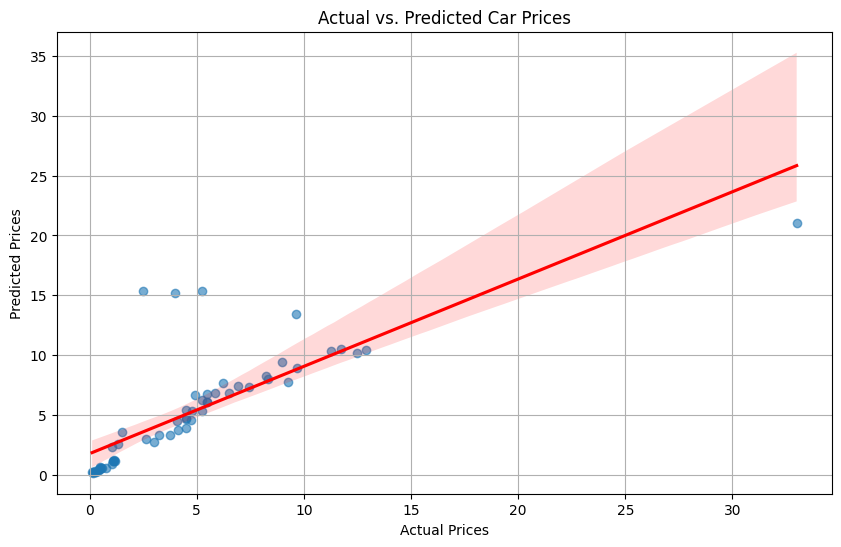

In [839]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Car Prices')
plt.grid(True)
plt.show()

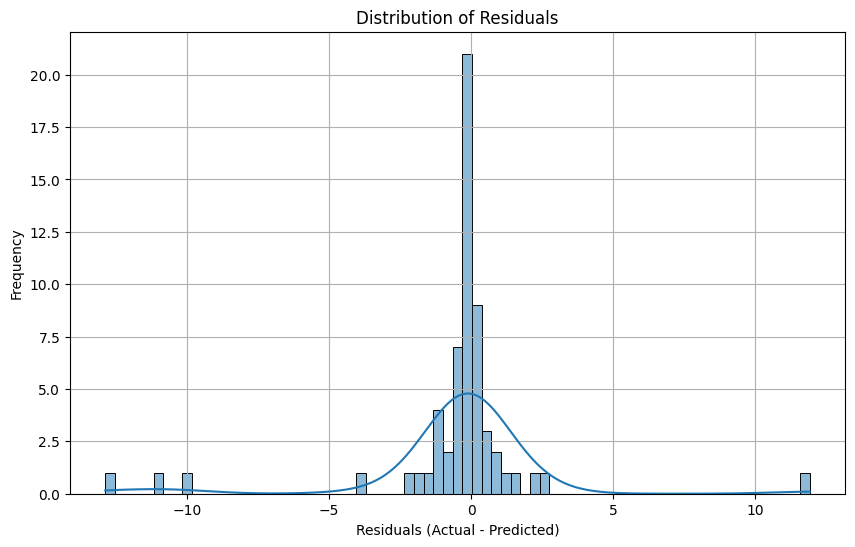

In [840]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True)
plt.show()

## 6. Feature Importance Analysis

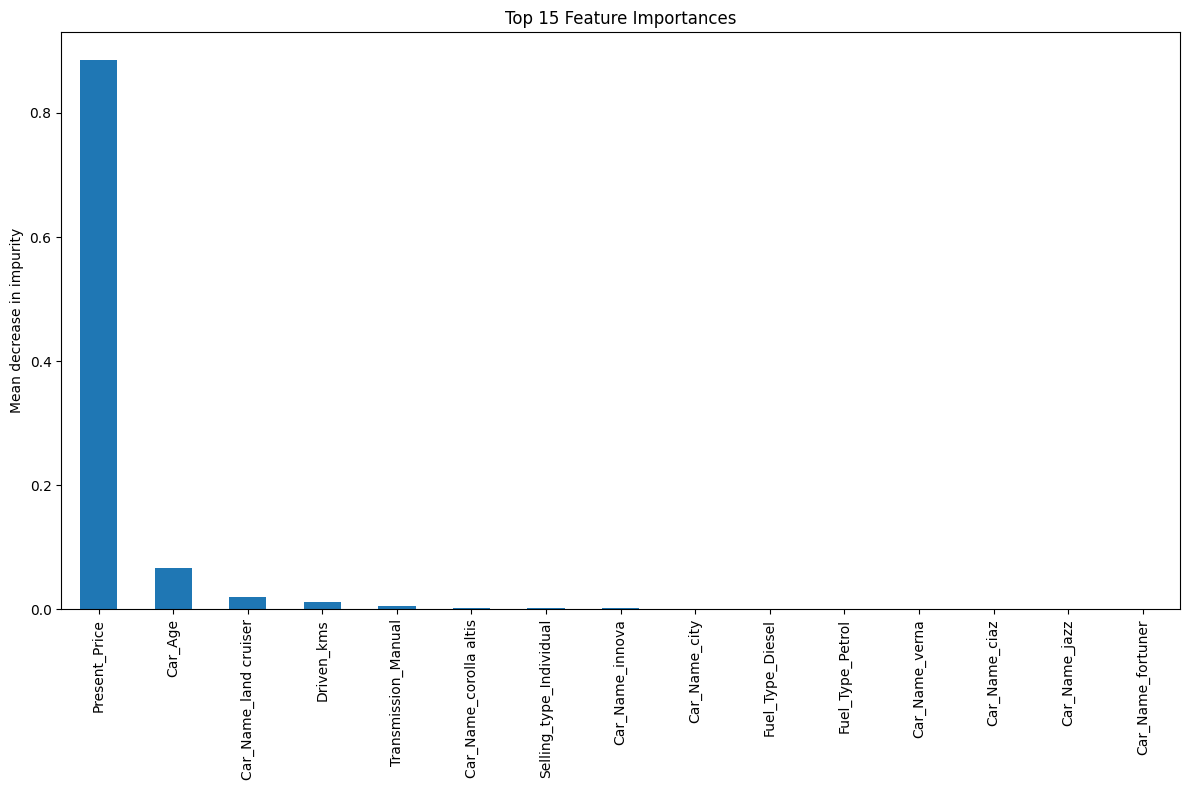

In [841]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(12, 8))
forest_importances.sort_values(ascending=False).head(15).plot.bar(ax=ax)
ax.set_title('Top 15 Feature Importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout()
plt.show()